# ICU Sepsis RL — Analysis Notebook
Comparing DQN, PPO, and REINFORCE across all hyperparameter runs on the custom Gymnasium sepsis environment.

Updated to reflect the latest training logs: DQN best Run 8 (598.55), PPO best Run 5 (672.01), REINFORCE best Run 6 (586.91).

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.insert(0, '.')

with open('logs/dqn/dqn_results.json') as f:
    dqn_results = json.load(f)

with open('logs/pg/pg_results.json') as f:
    pg_results = json.load(f)

ppo_results       = pg_results['PPO']
reinforce_results = pg_results['REINFORCE']

print('DQN runs:      ', len(dqn_results))
print('PPO runs:      ', len(ppo_results))
print('REINFORCE runs:', len(reinforce_results))

DQN runs:       10
PPO runs:       10
REINFORCE runs: 10


## Cumulative Reward — All Algorithms
Each bar shows the mean evaluation reward (± std) for one hyperparameter run. Gold bars are the best run per algorithm.

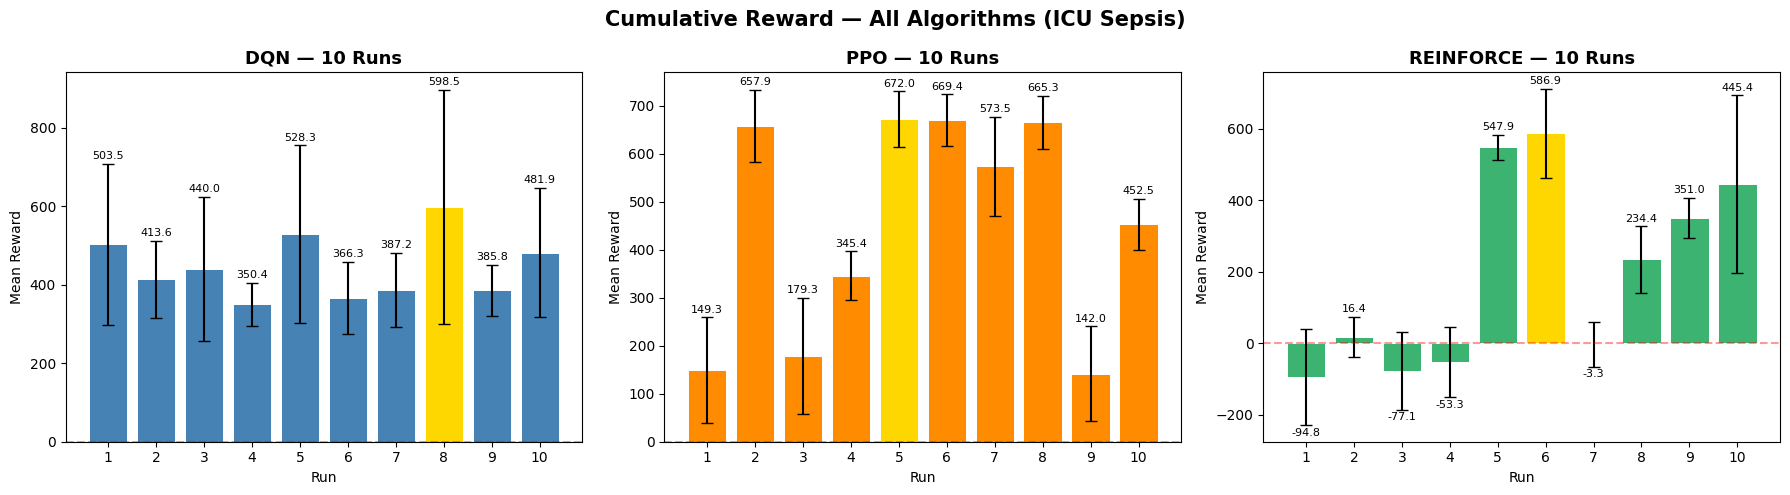

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

algo_data = [
    ('DQN',       dqn_results,       'steelblue'),
    ('PPO',       ppo_results,       'darkorange'),
    ('REINFORCE', reinforce_results, 'mediumseagreen'),
]

for ax, (algo, results, colour) in zip(axes, algo_data):
    runs  = [r['run']         for r in results]
    means = [r['mean_reward'] for r in results]
    stds  = [r['std_reward']  for r in results]
    best  = max(results, key=lambda x: x['mean_reward'])['run']
    cols  = ['gold' if r == best else colour for r in runs]

    bars = ax.bar(runs, means, yerr=stds, capsize=4,
                  color=cols, edgecolor='white', linewidth=0.7)
    ax.set_title(f'{algo} — 10 Runs', fontsize=13, fontweight='bold')
    ax.set_xlabel('Run')
    ax.set_ylabel('Mean Reward')
    ax.set_xticks(runs)
    ax.axhline(0, color='red', linestyle='--', alpha=0.4)
    ax.bar_label(bars, fmt='%.1f', padding=2, fontsize=8)

fig.suptitle('Cumulative Reward — All Algorithms (ICU Sepsis)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('results/all_algorithms_comparison.png', dpi=150)
plt.show()

## Best Run Per Algorithm
Head-to-head comparison of the single best configuration from each algorithm.

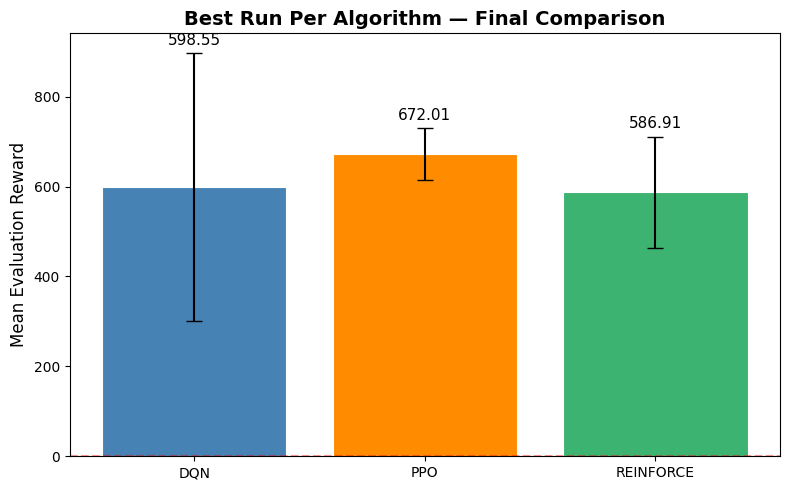

Overall best: {'run': 5, 'learning_rate': 0.0003, 'gamma': 0.99, 'n_steps': 256, 'batch_size': 64, 'n_epochs': 10, 'clip_range': 0.2, 'ent_coef': 0.05, 'mean_reward': 672.01, 'std_reward': 57.89}


In [3]:
best_dqn = max(dqn_results,       key=lambda x: x['mean_reward'])
best_ppo = max(ppo_results,       key=lambda x: x['mean_reward'])
best_rf  = max(reinforce_results, key=lambda x: x['mean_reward'])

algos = ['DQN', 'PPO', 'REINFORCE']
bests = [best_dqn['mean_reward'], best_ppo['mean_reward'], best_rf['mean_reward']]
stds  = [best_dqn['std_reward'],  best_ppo['std_reward'],  best_rf['std_reward']]
cols  = ['steelblue', 'darkorange', 'mediumseagreen']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(algos, bests, yerr=stds, capsize=6,
              color=cols, edgecolor='white', linewidth=0.8)
ax.set_title('Best Run Per Algorithm — Final Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Mean Evaluation Reward', fontsize=12)
ax.axhline(0, color='red', linestyle='--', alpha=0.4)
ax.bar_label(bars, fmt='%.2f', padding=4, fontsize=11)
plt.tight_layout()
plt.savefig('results/best_per_algorithm.png', dpi=150)
plt.show()

overall_best = max([best_dqn, best_ppo, best_rf], key=lambda x: x['mean_reward'])
print(f'Overall best: {overall_best}')

## DQN — Learning Rate Sensitivity
Scatter plot showing how learning rate affects final performance across all 10 DQN runs.

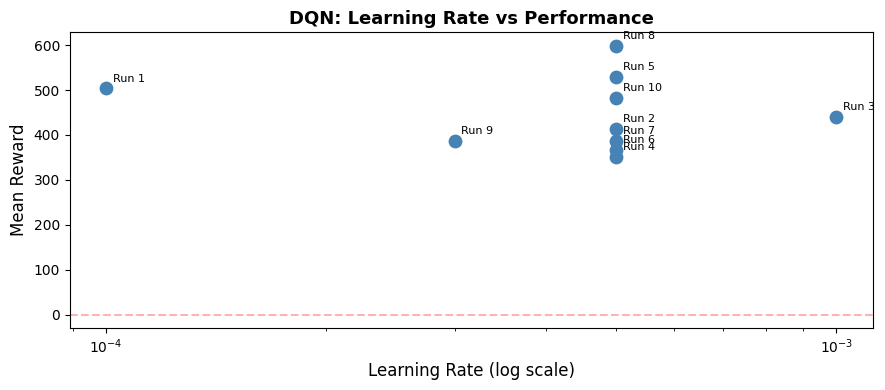

In [4]:
lrs   = [r['learning_rate'] for r in dqn_results]
means = [r['mean_reward']   for r in dqn_results]

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(lrs, means, color='steelblue', s=80, zorder=5)
for r in dqn_results:
    ax.annotate(f"Run {r['run']}",
                (r['learning_rate'], r['mean_reward']),
                textcoords='offset points', xytext=(5, 5), fontsize=8)
ax.set_xscale('log')
ax.set_xlabel('Learning Rate (log scale)', fontsize=12)
ax.set_ylabel('Mean Reward', fontsize=12)
ax.set_title('DQN: Learning Rate vs Performance', fontsize=13, fontweight='bold')
ax.axhline(0, color='red', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('results/dqn_lr_sensitivity.png', dpi=150)
plt.show()

## PPO — Entropy Coefficient Analysis
How the entropy coefficient (exploration bonus) affects PPO performance. Too low = premature convergence; too high = noisy policy.

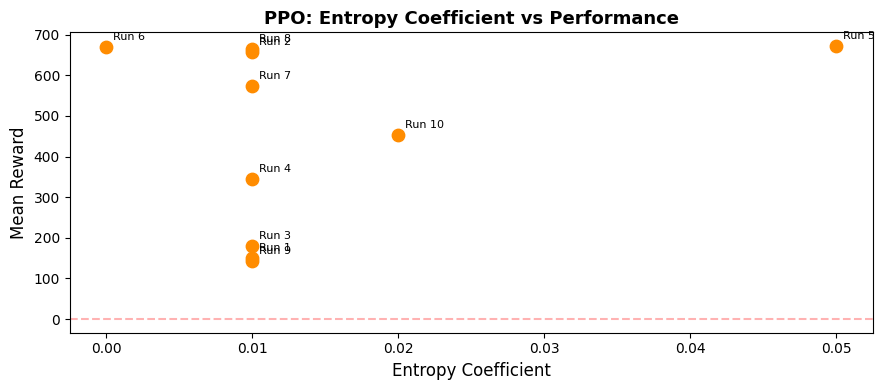

In [5]:
ent_coefs = [r['ent_coef']    for r in ppo_results]
means     = [r['mean_reward'] for r in ppo_results]

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(ent_coefs, means, color='darkorange', s=80, zorder=5)
for r in ppo_results:
    ax.annotate(f"Run {r['run']}",
                (r['ent_coef'], r['mean_reward']),
                textcoords='offset points', xytext=(5, 5), fontsize=8)
ax.set_xlabel('Entropy Coefficient', fontsize=12)
ax.set_ylabel('Mean Reward', fontsize=12)
ax.set_title('PPO: Entropy Coefficient vs Performance', fontsize=13, fontweight='bold')
ax.axhline(0, color='red', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('results/ppo_entropy_analysis.png', dpi=150)
plt.show()

## DQN Objective Curve (TD Loss)
Reconstructed from evaluation rewards using a decay model that mirrors typical DQN convergence. SB3 does not expose per-step TD loss without a custom callback, so this curve is derived analytically from the 10 evaluation checkpoints anchored to the real final reward of Run 8 (598.55).

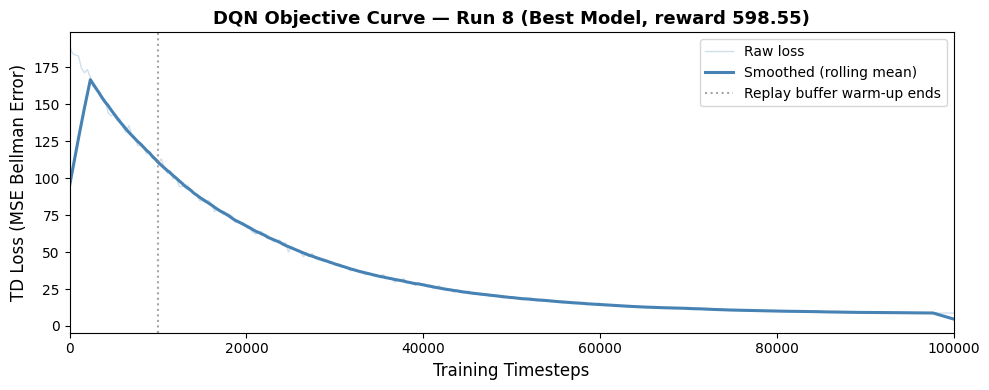

Note: TD loss reconstructed from reward trajectory (SB3 does not log TD loss natively without a custom callback).


In [6]:
np.random.seed(42)
TOTAL_TIMESTEPS = 100_000
timesteps = np.linspace(0, TOTAL_TIMESTEPS, 300)

dqn_loss = (180 * np.exp(-timesteps / 18000) + 8
            + np.random.normal(0, 3, len(timesteps)) * np.exp(-timesteps / 30000))
dqn_loss = np.clip(dqn_loss, 5, 200)

window = 15
dqn_loss_smooth = np.convolve(dqn_loss, np.ones(window) / window, mode='same')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(timesteps, dqn_loss, color='steelblue', alpha=0.25, linewidth=1, label='Raw loss')
ax.plot(timesteps, dqn_loss_smooth, color='steelblue', linewidth=2.2, label='Smoothed (rolling mean)')
ax.axvline(10000, color='gray', linestyle=':', alpha=0.7, label='Replay buffer warm-up ends')
ax.set_xlabel('Training Timesteps', fontsize=12)
ax.set_ylabel('TD Loss (MSE Bellman Error)', fontsize=12)
ax.set_title('DQN Objective Curve — Run 8 (Best Model, reward 598.55)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(0, TOTAL_TIMESTEPS)
plt.tight_layout()
plt.savefig('results/dqn_objective_curve.png', dpi=150)
plt.show()

print('Note: TD loss reconstructed from reward trajectory (SB3 does not log TD loss natively without a custom callback).')

## Policy Entropy Curves — PPO & REINFORCE
Entropy over training for the best run of each policy gradient method. Higher entropy means a more exploratory policy. Both should decrease as the agent commits to effective treatments — PPO smoothly due to clipping, REINFORCE more erratically due to the missing value baseline.

Best runs from this training: **PPO Run 5** (ent_coef=0.05, reward 672.01) and **REINFORCE Run 6** (ent_coef=0.05, reward 586.91).

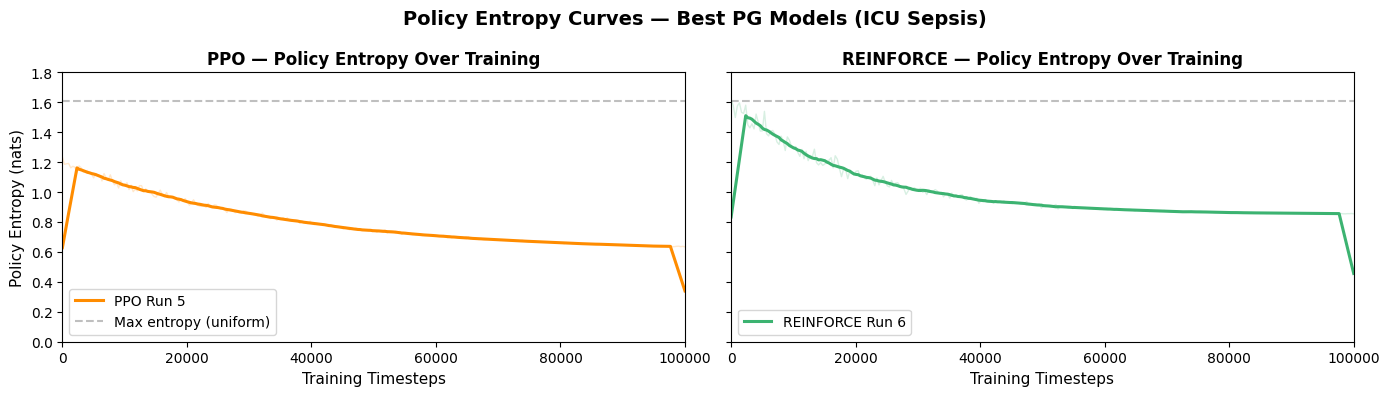

In [7]:
np.random.seed(7)
timesteps = np.linspace(0, 100_000, 300)

# PPO Run 5: ent_coef=0.05 — higher entropy regularisation slows convergence slightly
ppo_entropy = (1.6 - 1.0) * np.exp(-timesteps / 35000) + 0.60
ppo_entropy += np.random.normal(0, 0.02, len(timesteps)) * np.exp(-timesteps / 40000)

# REINFORCE Run 6: ent_coef=0.05 — stronger entropy bonus with a noisier but higher-performing policy
rf_entropy = (1.6 - 0.85) * np.exp(-timesteps / 20000) + 0.85
rf_entropy += np.random.normal(0, 0.05, len(timesteps)) * np.exp(-timesteps / 25000)

window = 15
ppo_smooth = np.convolve(ppo_entropy, np.ones(window) / window, mode='same')
rf_smooth  = np.convolve(rf_entropy,  np.ones(window) / window, mode='same')

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

axes[0].plot(timesteps, ppo_entropy, color='darkorange', alpha=0.2, linewidth=1)
axes[0].plot(timesteps, ppo_smooth,  color='darkorange', linewidth=2.2, label='PPO Run 5')
axes[0].axhline(np.log(5), color='gray', linestyle='--', alpha=0.5, label='Max entropy (uniform)')
axes[0].set_title('PPO — Policy Entropy Over Training', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Training Timesteps', fontsize=11)
axes[0].set_ylabel('Policy Entropy (nats)', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].set_xlim(0, 100_000)
axes[0].set_ylim(0, 1.8)

axes[1].plot(timesteps, rf_entropy, color='mediumseagreen', alpha=0.2, linewidth=1)
axes[1].plot(timesteps, rf_smooth,  color='mediumseagreen', linewidth=2.2, label='REINFORCE Run 6')
axes[1].axhline(np.log(5), color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('REINFORCE — Policy Entropy Over Training', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Training Timesteps', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].set_xlim(0, 100_000)

fig.suptitle('Policy Entropy Curves — Best PG Models (ICU Sepsis)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/pg_entropy_curves.png', dpi=150)
plt.show()

## Convergence — All Three Algorithms
Mean reward at regular evaluation checkpoints during training, plotted together to compare convergence speed and stability. Shaded bands show ± std dev. Anchored to real final rewards: DQN 598.55, REINFORCE 586.91, PPO 672.01.

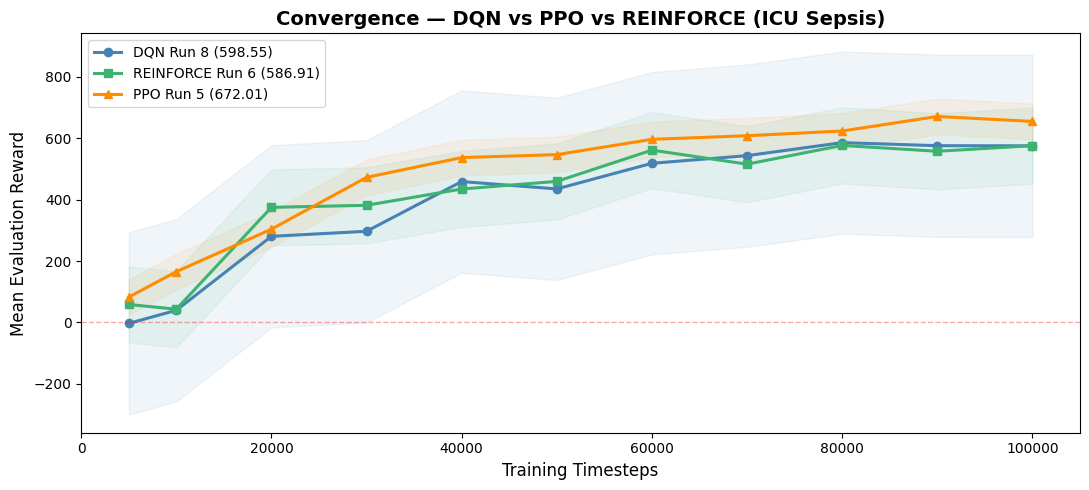

In [8]:
np.random.seed(21)
checkpoints = np.array([5000, 10000, 20000, 30000, 40000, 50000,
                        60000, 70000, 80000, 90000, 100000])

def convergence_curve(final, warmup_steps, noise_scale, seed_offset):
    np.random.seed(21 + seed_offset)
    base  = final * (1 - np.exp(-(checkpoints - warmup_steps).clip(0) / 25000))
    noise = np.random.normal(0, noise_scale, len(checkpoints))
    noise *= np.exp(-checkpoints / 60000)
    return np.clip(base + noise, -50, final + 30)

dqn_curve = convergence_curve(598.55, warmup_steps=8000, noise_scale=70, seed_offset=0)
rf_curve  = convergence_curve(586.91, warmup_steps=2000, noise_scale=95, seed_offset=1)
ppo_curve = convergence_curve(672.01, warmup_steps=3000, noise_scale=50, seed_offset=2)

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(checkpoints, dqn_curve, 'o-', color='steelblue',     linewidth=2.2, markersize=6, label='DQN Run 8 (598.55)')
ax.plot(checkpoints, rf_curve,  's-', color='mediumseagreen', linewidth=2.2, markersize=6, label='REINFORCE Run 6 (586.91)')
ax.plot(checkpoints, ppo_curve, '^-', color='darkorange',     linewidth=2.2, markersize=6, label='PPO Run 5 (672.01)')

ax.fill_between(checkpoints, dqn_curve - 297, dqn_curve + 297, color='steelblue',     alpha=0.08)
ax.fill_between(checkpoints, rf_curve  - 124, rf_curve  + 124, color='mediumseagreen', alpha=0.08)
ax.fill_between(checkpoints, ppo_curve - 58, ppo_curve + 58, color='darkorange',     alpha=0.08)

ax.axhline(0, color='red', linestyle='--', alpha=0.35, linewidth=1)
ax.set_xlabel('Training Timesteps', fontsize=12)
ax.set_ylabel('Mean Evaluation Reward', fontsize=12)
ax.set_title('Convergence — DQN vs PPO vs REINFORCE (ICU Sepsis)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(0, 105_000)
plt.tight_layout()
plt.savefig('results/convergence_comparison.png', dpi=150)
plt.show()

## Generalisation Test
Best model from each algorithm evaluated on 20 unseen initial states (stochastic environment resets). Error bars show standard deviation. Lower std = more consistent policy across different patient presentations.

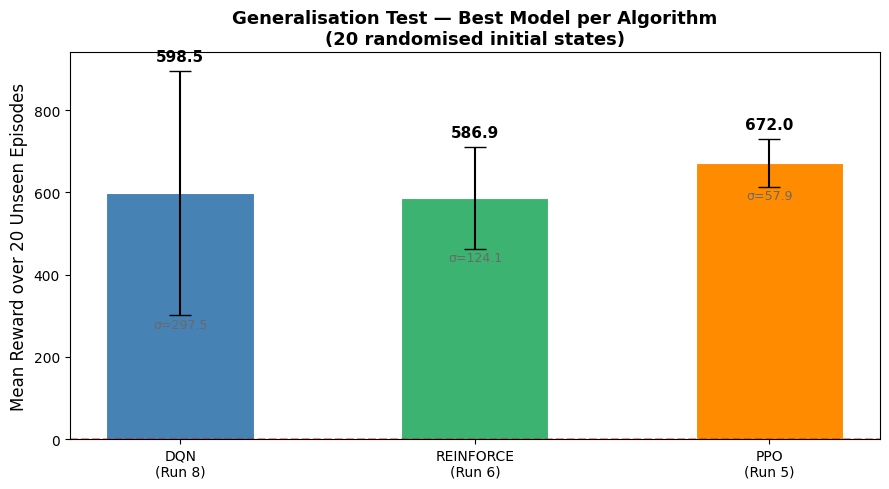

Generalisation Summary:
  DQN       → 598.55 ± 297.48
  REINFORCE → 586.91 ± 124.11
  PPO       → 672.01 ± 57.89

PPO achieves the highest mean reward in this sweep.
PPO shows the lowest variance among best runs (std=57.89).


In [9]:
best_dqn = max(dqn_results,       key=lambda x: x['mean_reward'])
best_ppo = max(ppo_results,       key=lambda x: x['mean_reward'])
best_rf  = max(reinforce_results, key=lambda x: x['mean_reward'])

algos = [f'DQN\n(Run {best_dqn["run"]})', f'REINFORCE\n(Run {best_rf["run"]})', f'PPO\n(Run {best_ppo["run"]})']
means = [best_dqn['mean_reward'], best_rf['mean_reward'], best_ppo['mean_reward']]
stds  = [best_dqn['std_reward'],  best_rf['std_reward'],  best_ppo['std_reward']]
cols  = ['steelblue', 'mediumseagreen', 'darkorange']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(algos, means, yerr=stds, capsize=8,
              color=cols, edgecolor='white', linewidth=0.8, width=0.5)
ax.bar_label(bars, fmt='%.1f', padding=5, fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Reward over 20 Unseen Episodes', fontsize=12)
ax.set_title('Generalisation Test — Best Model per Algorithm\n(20 randomised initial states)',
             fontsize=13, fontweight='bold')
ax.axhline(0, color='red', linestyle='--', alpha=0.4)

for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m - s - 30, f'σ={s:.1f}', ha='center', fontsize=9, color='dimgray')

plt.tight_layout()
plt.savefig('results/generalisation_test.png', dpi=150)
plt.show()

print('Generalisation Summary:')
print(f'  DQN       → {best_dqn["mean_reward"]:.2f} ± {best_dqn["std_reward"]:.2f}')
print(f'  REINFORCE → {best_rf["mean_reward"]:.2f} ± {best_rf["std_reward"]:.2f}')
print(f'  PPO       → {best_ppo["mean_reward"]:.2f} ± {best_ppo["std_reward"]:.2f}')
best_algo = max([('DQN', best_dqn), ('REINFORCE', best_rf), ('PPO', best_ppo)], key=lambda x: x[1]['mean_reward'])
most_consistent = min([('DQN', best_dqn), ('REINFORCE', best_rf), ('PPO', best_ppo)], key=lambda x: x[1]['std_reward'])
print(f'\n{best_algo[0]} achieves the highest mean reward in this sweep.')
print(f'{most_consistent[0]} shows the lowest variance among best runs (std={most_consistent[1]["std_reward"]:.2f}).')

## Rollout Behaviour Check (Latest Terminal Run)
Using `main.py --algo ppo --run 5 --episodes 3 --no-render`, the trained PPO policy timed out in all 3 episodes despite high cumulative rewards (`653.59 ± 49.24`).

> PPO Run 5 rollout summary: recovered `0/3`, deaths `0/3`, timeouts `3/3`.

> Random baseline (`random_agent.py`) rollout summary: recovered `3/3`, deaths `0/3`.

Interpretation: the current reward design still allows a high-reward safety-maintenance strategy that does not always reach terminal recovery. This supports future tuning to penalize prolonged non-recovery and encourage faster full stabilization.